# Sales Prediction using Python

In [1]:
#importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [2]:
#Dataset Loading...

df=pd.read_csv("Advertising.csv")

In [3]:
display(df.head(10))

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [4]:
# Dataset Overview and Summary

print("Dataset Summary:\n")
print(f"Missing Values in Dataset:\n{df.isna().sum()}")
print(f"Columns Names:\n{df.columns}")
print(f"Dataset Shape:\n{df.shape}")
print(f"columns datatypes:\n{df.dtypes}")
print(f"Statistical Summary:\n{df.describe()}")

Dataset Summary:

Missing Values in Dataset:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64
Columns Names:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')
Dataset Shape:
(200, 5)
columns datatypes:
Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object
Statistical Summary:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.

### Dataset Insights:

- *The dataset is clean ,with no missing values accross any column*
- *It contains 200 rows and 5 columns ,including one unnecessary index column (unnamed :0) that will be dropped in the next step*



In [5]:
# Dropping irrelevent columns

df=df.drop(columns=['Unnamed: 0'])

print("Dataset after dropping irrelevent column:\n ",df.shape)
df.head(10)

Dataset after dropping irrelevent column:
  (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


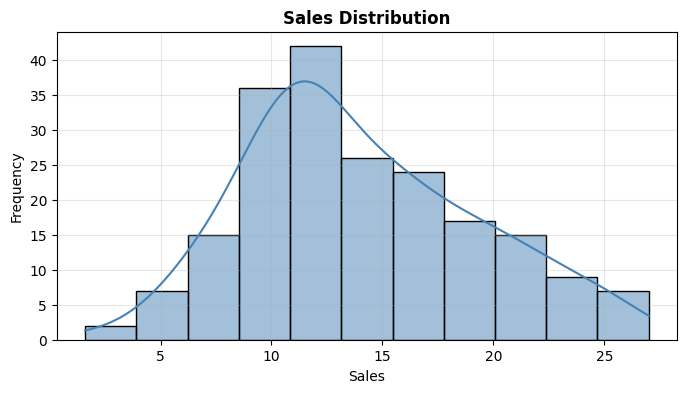

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(
    data=df,
    x='Sales',
    kde=True,
    color='steelblue'
)
plt.title("Sales Distribution",fontweight='bold')
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Sales Distribution
Insights:
Sales is mildly right-skewed, with most campaigns generating between 10-15 units in sales, and a smaller number of high-performing campaigns exceeding 20 units. The skew is not severe enough to require a transformation before modeling

## Sales vs Features

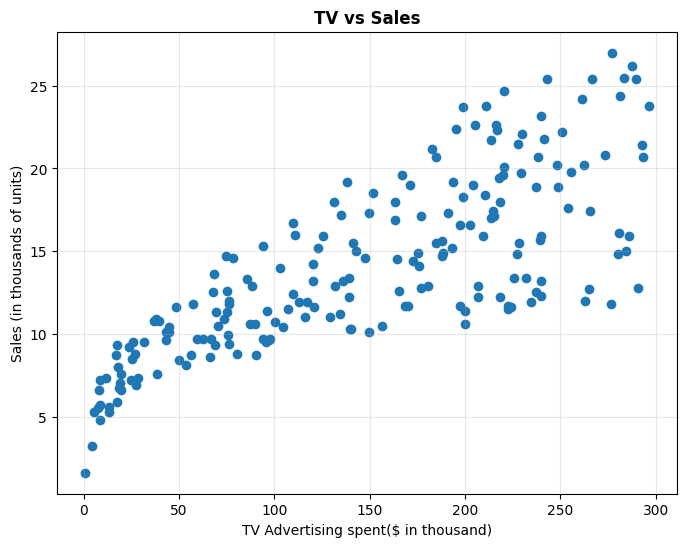

In [7]:
#Tv Advertising spent vs Sales

plt.figure(figsize=(8,6))
plt.scatter(df['TV'],df['Sales'])
plt.xlabel("TV Advertising spent($ in thousand)")
plt.ylabel("Sales (in thousands of units)")
plt.title("TV vs Sales",fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

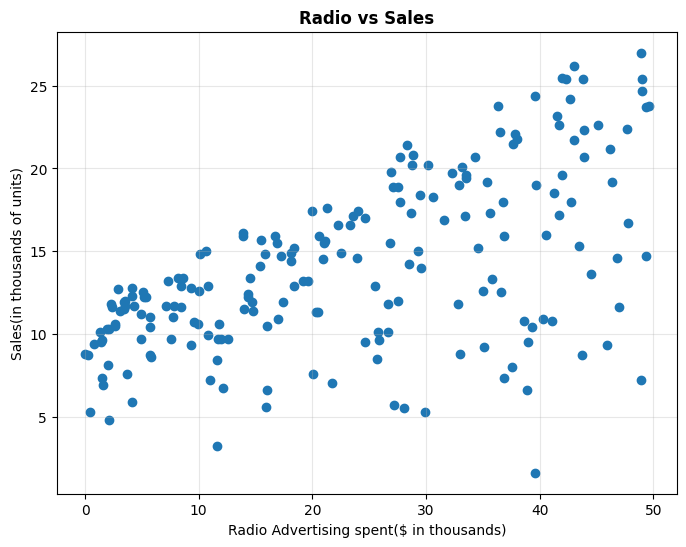

In [8]:
# Radio Advertising spent vs Sales

plt.figure(figsize=(8,6))
plt.scatter(df['Radio'],df['Sales'])
plt.xlabel("Radio Advertising spent($ in thousands)")
plt.ylabel("Sales(in thousands of units)")
plt.title("Radio vs Sales",fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

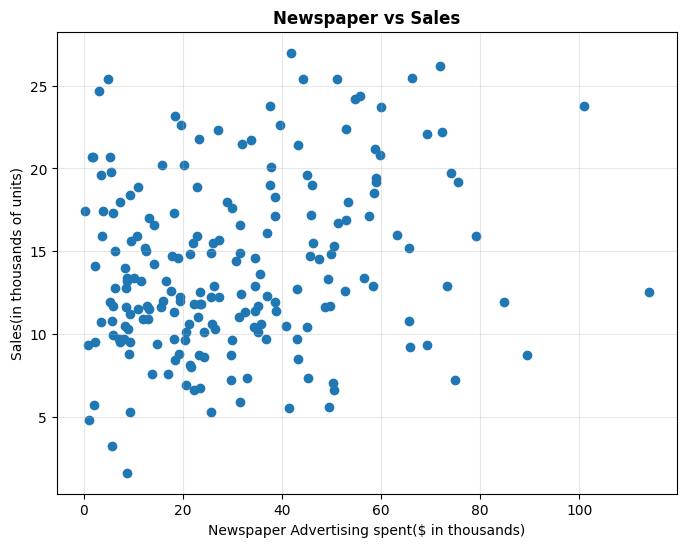

In [9]:
# Newspaper Avertising spent vs Sales

plt.figure(figsize=(8,6))
plt.scatter(df['Newspaper'],df['Sales'])
plt.xlabel("Newspaper Advertising spent($ in thousands)")
plt.ylabel("Sales(in thousands of units)")
plt.title("Newspaper vs Sales",fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

Feature vs Sales Scatter Plots 

Insights:
TV spend shows the strongest positive relationship with Sales, Radio shows a moderate positive relationship, and Newspaper shows little to no clear relationship with Sales.

## Outlier Detection

In [10]:
print("OUTLIERS:\n")
for col in ['TV','Newspaper','Radio']:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-(1.5 * IQR)
    upper=Q3 +(1.5 * IQR)
    outliers=df[(df[col]<lower) | (df[col]>upper)].shape[0]
    print(f"{col}:{outliers}")

OUTLIERS:

TV:0
Newspaper:2
Radio:0


Outlier Detection

Insights:
Using the IQR method, no outliers were found in TV or Radio spend, while only 2 outliers were detected in Newspaper spend out of 200 records. Given the small number and the dataset's overall clean structure, these values will retained rather than removed.

## Correlation Analysis

In [11]:
#Relationship between features and target variable (Advertising spent and Sales)

correlation=df.corr()
display(correlation)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


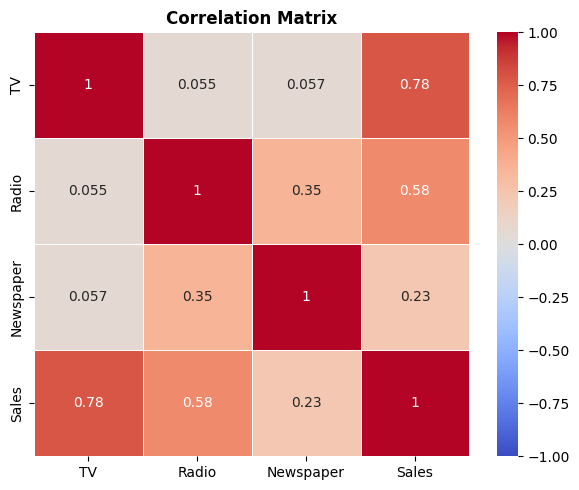

In [12]:

plt.figure(figsize=(6,5))
sns.heatmap(correlation,annot=True,cmap='coolwarm',linewidths=0.5,vmin=-1,vmax=1)
plt.title("Correlation Matrix",fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_matrix.png",dpi=300)
plt.show()


### Correlation Insights:

- *Sales shows a strong correlation with TV advertising (0.78), higher than any other feature.*

- *Radio shows a moderate correlation with Sales (0.58).*

- *Newspaper shows a weak correlation with Sales (0.23).*

- *Overall, TV advertising is the most influential factor in driving Sales, while Newspaper spend has minimal impact — reinforcing what was observed in the scatter plots.*

## Feature Engineering



In [13]:
# TV and Radio interaction effect 
df['TV_Radio_interaction']=df['TV']*df['Radio'] #Adding new feature to dataset!

df['TV_Radio_interaction'].corr(df['Sales'])




np.float64(0.963932045992048)

In [14]:
print(f"Correlation table after adding new feature:\n{df.corr()}")

Correlation table after adding new feature:
                            TV     Radio  Newspaper     Sales  \
TV                    1.000000  0.054809   0.056648  0.782224   
Radio                 0.054809  1.000000   0.354104  0.576223   
Newspaper             0.056648  0.354104   1.000000  0.228299   
Sales                 0.782224  0.576223   0.228299  1.000000   
TV_Radio_interaction  0.662160  0.681392   0.251706  0.963932   

                      TV_Radio_interaction  
TV                                0.662160  
Radio                             0.681392  
Newspaper                         0.251706  
Sales                             0.963932  
TV_Radio_interaction              1.000000  


In [15]:
df.shape

(200, 5)

### Insights:
*New feature shows a strong correlation with sales (0.96)*

## Train/Test Split

In [16]:
X=df[['TV','Newspaper','Radio','TV_Radio_interaction']]
Y=df['Sales']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,)

print(f"Training Size:{X_train.shape}")
print(f"Testing Size:{X_test.shape}")

Training Size:(160, 4)
Testing Size:(40, 4)


## Modeling

- ### Linear Regression

In [17]:
model_1=LinearRegression()

model_1.fit(X_train,Y_train)

model_1_train_prediction=model_1.predict(X_train)
model_1_test_prediction=model_1.predict(X_test)

model_1_train_rmse=np.sqrt(mean_squared_error(Y_train,model_1_train_prediction))
model_1_test_rmse=np.sqrt(mean_squared_error(Y_test,model_1_test_prediction))

model_1_train_r2=r2_score(Y_train,model_1_train_prediction)
model_1_test_r2=r2_score(Y_test,model_1_test_prediction)

print("coefficients (b1,b2,b3,b4):",model_1.coef_)
print("Intercept:",model_1.intercept_)

print("Linear Regression model Accuracy:\n")
print(f"Training RMSE scores:{model_1_train_rmse}")
print(f"Testing RMSE scores:{model_1_test_rmse}")
print(f"Training R2 scores:{model_1_train_r2}")
print(f"Testing R2 scores:{model_1_test_r2}")


coefficients (b1,b2,b3,b4): [0.01961507 0.00190677 0.03397467 0.00104987]
Intercept: 6.649882865325846
Linear Regression model Accuracy:

Training RMSE scores:0.9438880164891589
Testing RMSE scores:0.9024580782957334
Training R2 scores:0.9656494447858947
Testing R2 scores:0.9741971529119294


- ### Ridge Regression

In [18]:
#Scaling the features using StandardScaler for Ridge and Lasso Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [19]:
model_2=Ridge(alpha=10,random_state=42)
model_2.fit(X_train_scaled,Y_train)

model_2_train_prediction=model_2.predict(X_train_scaled)
model_2_test_prediction=model_2.predict(X_test_scaled)

model_2_train_rmse=np.sqrt(mean_squared_error(Y_train,model_2_train_prediction))
model_2_test_rmse=np.sqrt(mean_squared_error(Y_test,model_2_test_prediction))

model_2_train_r2=r2_score(Y_train,model_2_train_prediction)
model_2_test_r2=r2_score(Y_test,model_2_test_prediction)

print("\n Ridge Model Accuracy:\n")
print(f"Training RMSE scores:{model_2_train_rmse}")
print(f"Testing RMSE scores:{model_2_test_rmse}")
print(f"Training R2 scores:{model_2_train_r2}")
print(f"Testing R2 scores:{model_2_test_r2}")


 Ridge Model Accuracy:

Training RMSE scores:0.9743852755637462
Testing RMSE scores:1.0086699070968836
Training R2 scores:0.9633938342961902
Testing R2 scores:0.9677661869069382


## Cross Validation

In [20]:
from sklearn.model_selection import cross_val_score

model_1_cv_scores=cross_val_score(model_1,X,Y,scoring='r2')
print("Linear Regression CV scores:\n",model_1_cv_scores)
print("Mean :",model_1_cv_scores.mean())

Linear Regression CV scores:
 [0.97448681 0.97382966 0.96654313 0.9218093  0.98418323]
Mean : 0.9641704265806471


In [21]:
from sklearn.model_selection import cross_val_score

model_2_cv_scores=cross_val_score(model_2,X,Y,scoring='r2')
print("Ridge Regression CV scores:\n",model_2_cv_scores)
print("Mean :",model_2_cv_scores.mean())

Ridge Regression CV scores:
 [0.97448587 0.97383294 0.96653731 0.92183025 0.98418101]
Mean : 0.9641734783215601


Cross-Validation

Insights:
Both Linear Regression and Ridge Regression achieved nearly identical mean R² scores (~0.964) across 5 folds. One fold scored slightly lower (R²=0.92) than the rest, but overall performance remained strong and consistent, indicating the models generalize well across different subsets of the data.

## **Final Insights and Recommendations:**
This project analyzed how TV, Radio, and Newspaper advertising spend relate to Sales, using correlation analysis, feature engineering, and two regression models validated through cross-validation.

### Key Findings:

- TV advertising is the strongest individual driver of Sales (correlation = 0.78), followed by Radio (0.58), while Newspaper shows a weak relationship (0.23).


- A strong synergy effect exists between TV and Radio: their combined interaction term correlates with Sales at 0.96, far higher than either channel alone  indicating that running TV and Radio campaigns together produces disproportionately higher sales than either channel individually.


- Both Linear Regression and Ridge Regression performed nearly identically (mean R² ≈ 0.96 across 5-fold cross-validation), confirming the model's predictions are reliable and not dependent on a single lucky data split.


- No significant outliers were found in the dataset, and multicollinearity, while present between the interaction term and its parent features, was not severe enough to affect model performance.


## Business Recommendations:

Prioritize combined TV and Radio campaigns over running either channel in isolation, given the strong synergy effect discovered.
Reconsider Newspaper advertising spend, its weak, inconsistent relationship with Sales suggests this budget could be reduced or reallocated toward TV and Radio without a meaningful loss in sales performance.
Given the model's strong, consistent accuracy (R² ≈ 0.96), it can be reasonably used to forecast expected sales outcomes for future advertising budget allocations.

-------------------------------------------------------------------------------------------------------------------------------------------------